In [34]:
import os
import torch
import pandas as pd
from pathlib import Path

# Path to the split dataset
data_dir = Path("/global/cfs/cdirs/m3246/gregork/Minerva/20260201_all_max_blobs_and_prongs_split_fix_anomalies")

# Get all dataset names
datasets = sorted([d for d in os.listdir(data_dir) if os.path.isdir(data_dir / d)])
# remove "baselines" from the split dataset
if "baselines" in datasets:
    datasets.remove("baselines")


In [35]:
# Dictionary to store counts
counts = {}

# Iterate through each dataset
for dataset in datasets:
    dataset_path = data_dir / dataset
    counts[dataset] = {}
    
    # Count events in each split (train, val, test)
    for split in ['train', 'val', 'test']:
        split_path = dataset_path / split / "0.pb"
        
        if split_path.exists():
            # Load the data
            data = torch.load(split_path, weights_only=False)
            # Count the number of events (first dimension of truth_labels)
            n_events = data['truth_labels'].shape[0]
            counts[dataset][split] = n_events
        else:
            counts[dataset][split] = 0

# Create a DataFrame for nice table display
df = pd.DataFrame(counts).T
df = df[['train', 'val', 'test']]  # Ensure column order

# Add a total column
df['total'] = df.sum(axis=1)

# Add a row for totals
df.loc['Total'] = df.sum()

# Convert to millions
df_millions = df / 1_000_000

print("Number of events per dataset and split (in millions):")
print("=" * 60)
print(df_millions.round(2))
print("=" * 60)

Number of events per dataset and split (in millions):
       train   val  test  total
1A      6.08  0.76  0.76    7.6
Total   6.08  0.76  0.76    7.6


In [ ]:
import torch._dynamo

# Load data from multiple datasets for comparison
# You can modify this list to select which datasets to compare
#datasets_to_plot = datasets  # Use all datasets, or specify like: ["1A", "1B"]

datasets_to_plot = {
    "Minerva_v2": "/global/cfs/cdirs/m3246/gregork/Minerva/20260201_all_max_blobs_and_prongs_split_fix_anomalies/1A",
    "Minerva_v1": "/global/cfs/cdirs/m3246/gregork/Minerva/20260129_split_all/1A"
}

loaded_datasets = {}
for dataset in datasets_to_plot:
    split_path = Path(datasets_to_plot[dataset]) / "train" / "0.pb"
    
    if split_path.exists():
        # Load the data
        loaded_datasets[dataset] = torch.load(split_path, weights_only=True, mmap=True)
        print(f"Loaded dataset: {dataset}")

Loaded dataset: Minerva_v2
Loaded dataset: Minerva_v1


In [48]:
loaded_datasets.keys()

dict_keys(['Minerva_v2', 'Minerva_v1'])

In [49]:
#vals = data["data"].values()
#offsets = data["data"].offsets()
vals = {key: data["data"].values() for key, data in loaded_datasets.items()}
offsets = {key: data["data"].offsets() for key, data in loaded_datasets.items()}

In [50]:
vals.keys()

dict_keys(['Minerva_v2', 'Minerva_v1'])

In [51]:
event_id = 72
vals["Minerva_v1"][offsets["Minerva_v1"][event_id]:offsets["Minerva_v1"][event_id+1]]

tensor([[ 2.6311, -1.5109,  6.5357,  8.4790,  0.0000],
        [ 2.8917,  2.0944, -2.1086,  0.0930,  2.0000],
        [ 3.0632,  3.1416,  0.4100,  2.7822,  2.0000],
        [ 5.8878, -2.0944, -3.2003,  1.9944,  2.0000],
        [ 2.6311, -1.5109,  6.5357,  8.4790,  3.0000],
        [ 0.9908,  1.7814,  6.0372,  7.0359,  4.0000]], dtype=torch.float64)

In [52]:
vals["Minerva_v2"][offsets["Minerva_v2"][event_id]:offsets["Minerva_v2"][event_id+1]]

tensor([[ 2.6311, -1.5109,  6.5357,  8.4790,  0.0000],
        [ 2.8917,  2.0944, -2.1086,  0.0930,  2.0000],
        [ 3.0632,  3.1416,  0.4100,  2.7822,  2.0000],
        [ 5.8878, -2.0944, -3.2003,  1.9944,  2.0000],
        [ 2.6311, -1.5109,  6.5357,  8.4790,  3.0000],
        [ 0.9908,  1.7814,  6.0372,  7.0359,  4.0000]], dtype=torch.float64)

In [53]:
import matplotlib.pyplot as plt
def plot_histogram_matrix(title, matrix_dict, feature_names=None):
    # Matrix is of dim (N, n_features)
    # For each feature, make a histogram
    # plot matrix_dict on the same plot
    matrix = matrix_dict[list(matrix_dict.keys())[0]]
    fig, axs = plt.subplots(matrix.shape[1], 2, figsize=(12.5, 20))
    for i in range(matrix.shape[1]):
        for key, matrix in matrix_dict.items():
            axs[i, 0].hist(matrix[:, i], bins=100, histtype='step', label=key)
            axs[i, 1].hist(matrix[:, i], bins=100, histtype='step', label=key)
            axs[i, 1].set_yscale('log')
        if feature_names is None:
            axs[i, 0].set_title(f"Feature {i}")
            axs[i, 0].set_title(f"Feature {i} (log)")
        else:
            axs[i, 0].set_title(feature_names[i])
            axs[i, 1].set_title(feature_names[i])
        axs[i, 0].legend()
        axs[i, 1].legend()
    fig.suptitle(title)
    return fig



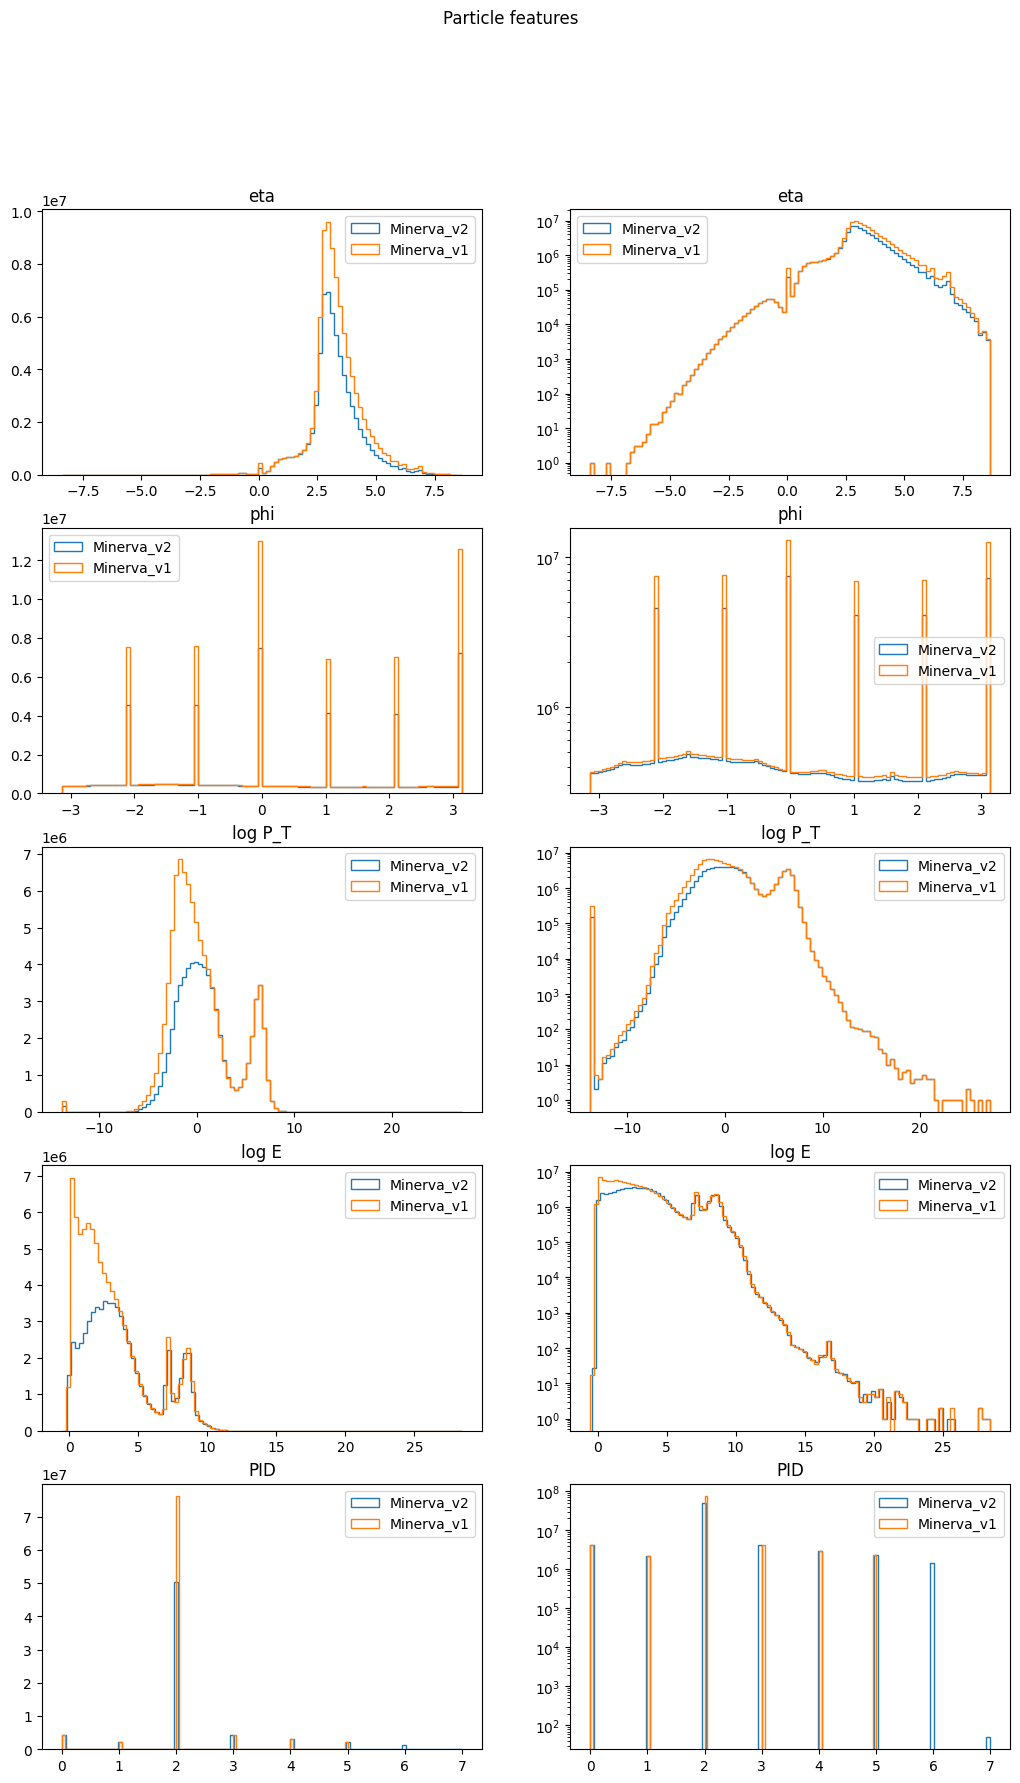

In [54]:
plot_histogram_matrix("Particle features", vals, ["eta", "phi", "log P_T", "log E", "PID"]).show()

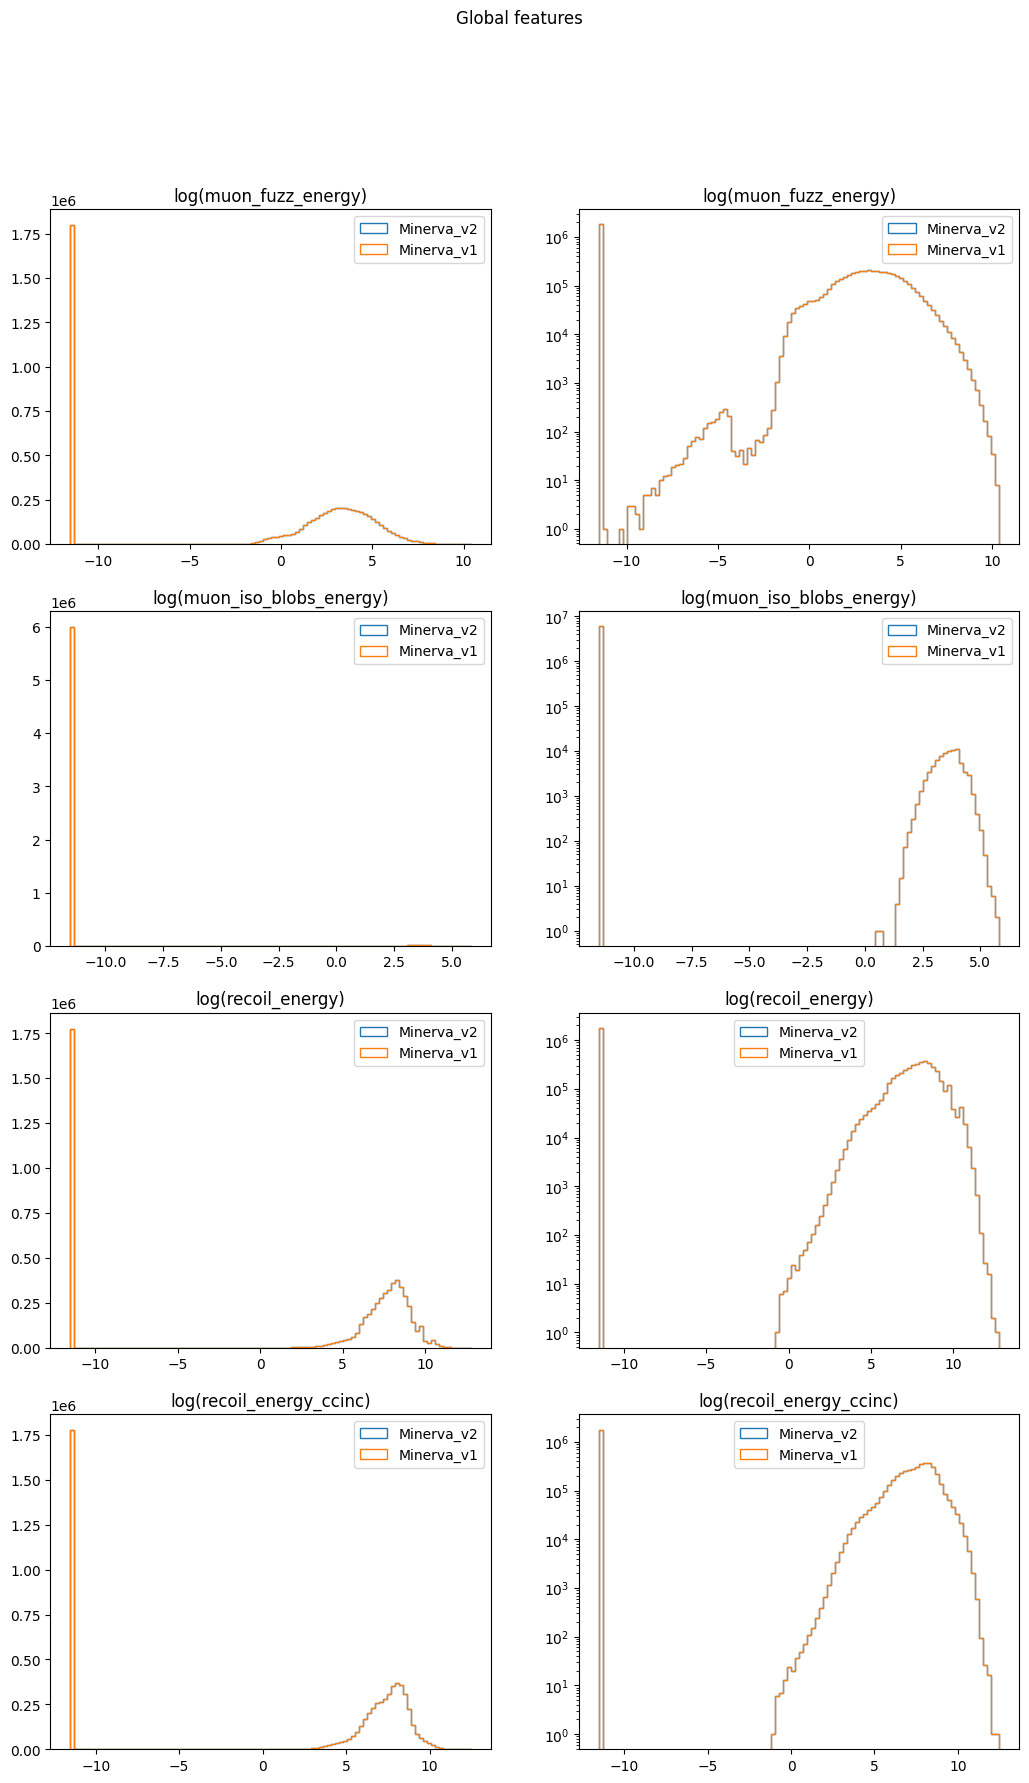

In [55]:
plot_histogram_matrix("Global features", {key: data["global_features"] for key, data in loaded_datasets.items()}, ["log(muon_fuzz_energy)", "log(muon_iso_blobs_energy)", "log(recoil_energy)", "log(recoil_energy_ccinc)"]).show()

In [56]:
data["truth_labels"][:, 2] /= data["truth_labels"][:, 0] 

In [57]:
data["truth_labels"].shape

torch.Size([760041, 4])

IndexError: index 3 is out of bounds for dimension 1 with size 3

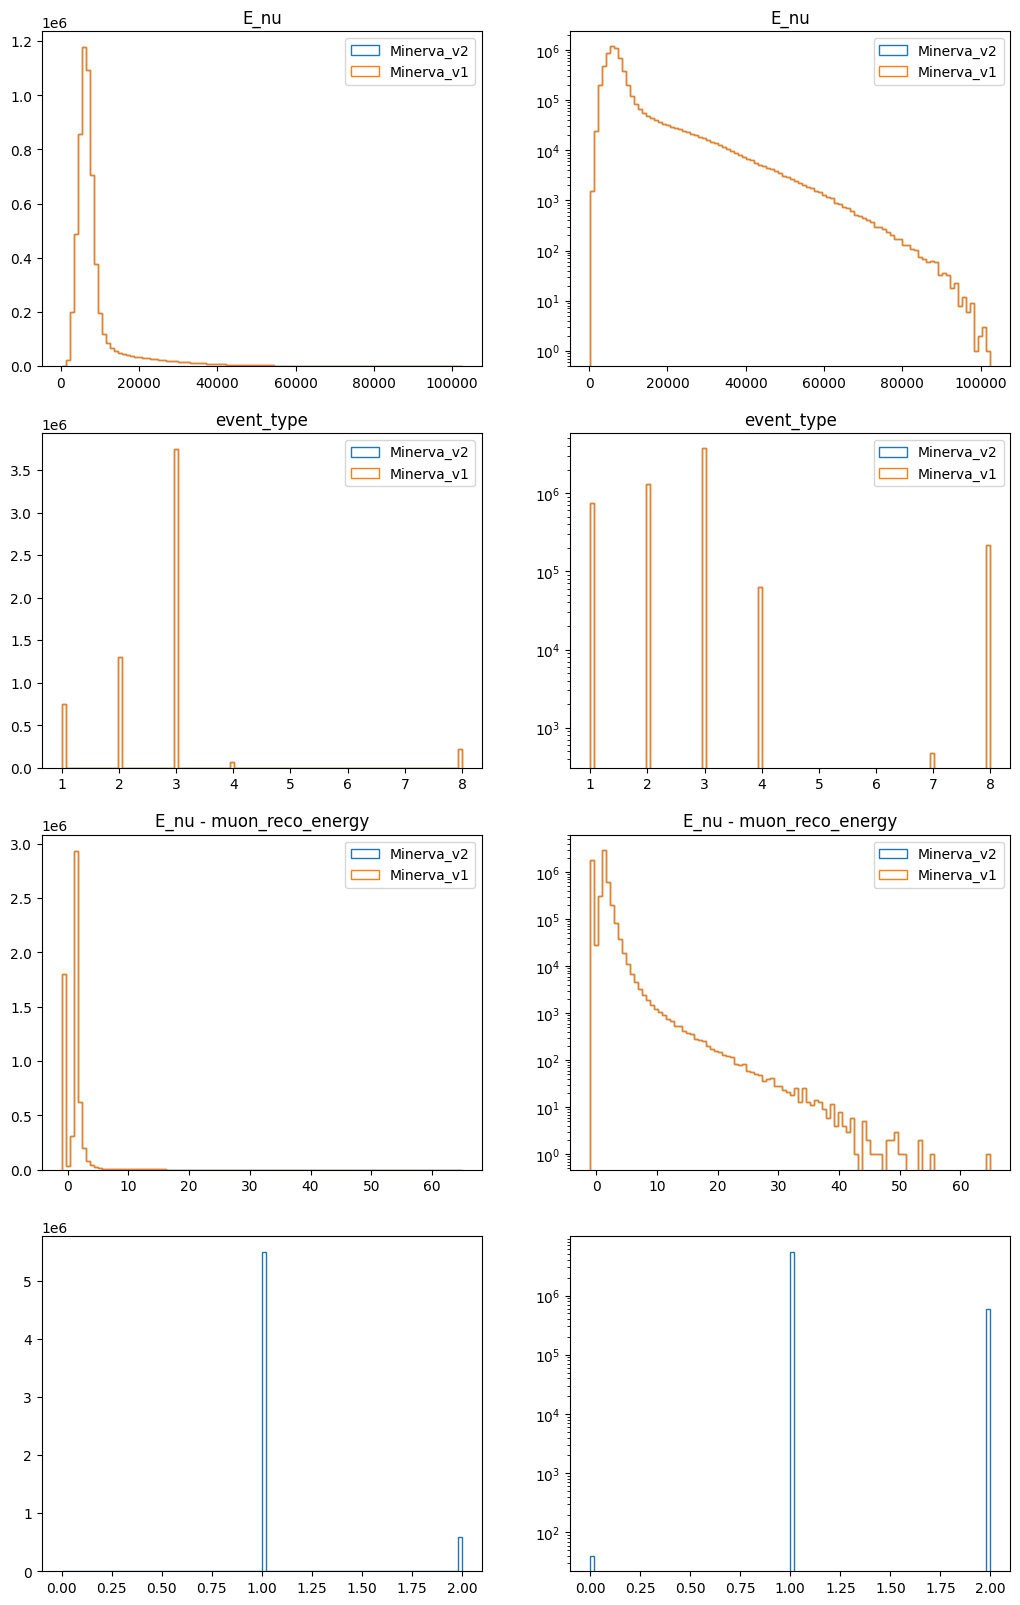

In [58]:
plot_histogram_matrix("GT labels", {key: data["truth_labels"] for key, data in loaded_datasets.items()}, ["E_nu", "event_type", "E_nu - muon_reco_energy", "current_type"]).show()

In [ ]:
import numpy as np
# check particles with logE <-10 and print their eta, phi, logP_T, logE, PID
particles = vals[np.where(vals[:, 3] < -10)]
print(particles.shape, particles, particles[:, -1])


KeyError: (slice(None, None, None), 3)

In [ ]:
# Compute muon_reco_energy for each dataset
muon_reco_energies = {}
for dataset_name, data in loaded_datasets.items():
    muon_reco_energies[dataset_name] = -data["truth_labels"][:, 2] + data["truth_labels"][:, 0]
    print(f"Computed muon_reco_energy for {dataset_name}")

Computed muon_reco_energy for Minerva_v2
Computed muon_reco_energy for Minerva_v1


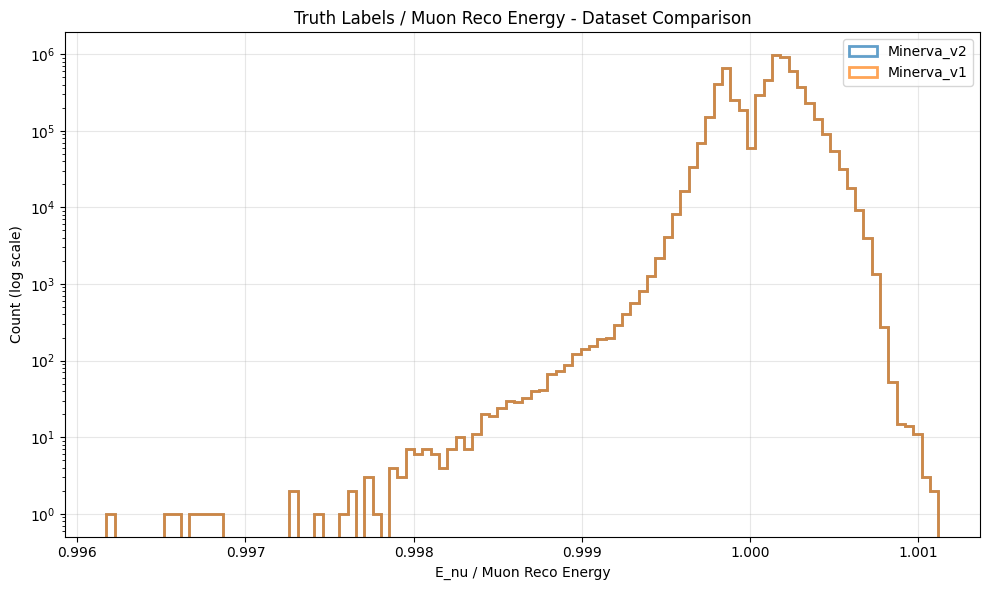

In [ ]:
import matplotlib.pyplot as plt

# Plot histograms for all datasets on the same plot
fig, ax = plt.subplots(figsize=(10, 6))

for dataset_name, data in loaded_datasets.items():
    muon_reco_energy = muon_reco_energies[dataset_name]
    
    # Plot histogram with step style for better visibility when overlapping
    ax.hist(data["truth_labels"][:, 0] / muon_reco_energy, 
            bins=100, 
            alpha=0.7, 
            label=dataset_name,
            histtype='step',
            linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('E_nu / Muon Reco Energy')
ax.set_ylabel('Count (log scale)')
ax.set_title('Truth Labels / Muon Reco Energy - Dataset Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
# Compute number of tokens per event for each dataset
n_tokens_dict = {}
for dataset_name, data in loaded_datasets.items():
    offsets = data["data"].offsets()
    n_tokens_dict[dataset_name] = offsets[1:] - offsets[:-1]
    print(f"Computed n_tokens for {dataset_name}: mean={n_tokens_dict[dataset_name].float().mean():.2f}")

Computed n_tokens for Minerva_v2: mean=11.17
Computed n_tokens for Minerva_v1: mean=15.15


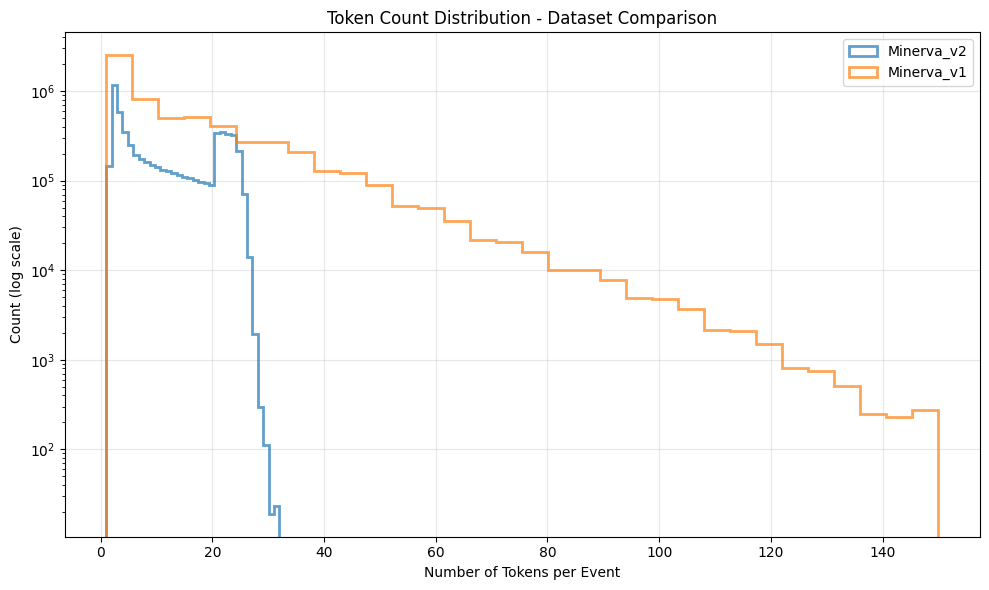

In [ ]:
# Plot number of tokens histogram for all datasets
fig, ax = plt.subplots(figsize=(10, 6))

for dataset_name, n_tokens in n_tokens_dict.items():
    ax.hist(n_tokens, 
            bins=32, 
            alpha=0.7, 
            label=dataset_name,
            histtype='step',
            linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('Number of Tokens per Event')
ax.set_ylabel('Count (log scale)')
ax.set_title('Token Count Distribution - Dataset Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
data = loaded_datasets["Minerva_v2"]

In [ ]:
data["truth_labels"].shape

torch.Size([6080806, 4])

In [59]:

import numpy as np

mc_current = data["truth_labels"][:, -1]
mc_intType = data["truth_labels"][:, 1]

# Get unique values for both variables
unique_currents = torch.unique(mc_current)
unique_intTypes = torch.unique(mc_intType)

# Create a cross-tabulation table
from tabulate import tabulate

# Build table data: each row is [current, count for intType1, count for intType2, ..., total]
table_data = []
total_events = len(mc_current)

for current in unique_currents:
    row = [f"Current {current}"]
    row_total = 0
    
    for intType in unique_intTypes:
        count = torch.sum((mc_current == current) & (mc_intType == intType))
        percentage = count / total_events * 100
        row.append(f"{count}\n({percentage:.2f}%)")
        row_total += count
    
    row.append(f"{row_total}\n({row_total/total_events*100:.2f}%)")
    table_data.append(row)

# Add column totals
totals_row = ["Total"]
for intType in unique_intTypes:
    count = torch.sum(mc_intType == intType)
    percentage = count / total_events * 100
    totals_row.append(f"{count}\n({percentage:.2f}%)")
totals_row.append(f"{total_events}\n(100.00%)")
table_data.append(totals_row)

# Create headers
headers = ["mc_current \\ mc_intType"] + [f"intType {t}" for t in unique_intTypes] + ["Total"]

# Print the table
print(tabulate(table_data, headers=headers, tablefmt="grid"))

+---------------------------+---------------+---------------+---------------+---------------+---------------+-----------+
| mc_current \ mc_intType   | intType 1.0   | intType 2.0   | intType 3.0   | intType 4.0   | intType 8.0   | Total     |
+===========================+===============+===============+===============+===============+===============+===========+
| Current 1.0               | 93263         | 156905        | 401565        | 6766          | 27187         | 685686    |
|                           | (12.27%)      | (20.64%)      | (52.83%)      | (0.89%)       | (3.58%)       | (90.22%)  |
+---------------------------+---------------+---------------+---------------+---------------+---------------+-----------+
| Current 2.0               | 290           | 5904          | 66966         | 1195          | 0             | 74355     |
|                           | (0.04%)       | (0.78%)       | (8.81%)       | (0.16%)       | (0.00%)       | (9.78%)   |
+-----------------------

In [67]:

def get_class_counts(class_idx, label_idx_to_class_idx, files_truth_labels, truth_labels_idx):
    n_class = len(class_idx)
    class_counts = np.zeros(n_class)
    for file_idx in range(len(files_truth_labels)):
        labels = files_truth_labels[file_idx][:, truth_labels_idx] # labels contain 1's and 2's, rewrite them into 0's and 1's based on class_idx indices of 1 and 2 in there
        # 'rewrite' labels in a way 
        labels = np.array([label_idx_to_class_idx[label.item()] for label in labels])
        class_counts += np.bincount(labels, minlength=n_class)
    return class_counts

get_class_counts(np.array([1, 2]), {1: 0, 2: 1}, [data["truth_labels"]], -1)

array([685686.,  74355.])

In [68]:
get_class_counts(np.array([1, 2]), {1: 0, 2: 1}, [data["truth_labels"]], -1)

array([685686.,  74355.])

In [69]:
get_class_counts(np.array([1, 2, 3, 4, 8]), {1: 0, 2: 1, 3: 2, 4: 3, 8: 4}, [data["truth_labels"]], 1)

array([ 93553., 162809., 468531.,   7961.,  27187.])